In [20]:
#1
!pip -q install tensorflow scikit-learn matplotlib seaborn

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import time, random, pickle
import os

SEED = 42
np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)
print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

TF: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [21]:
#mounting
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
#2

FILE_PATH = '/content/drive/MyDrive/CSC330_Project/RML2016.10a_dict.pkl'

with open(FILE_PATH, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

print("Keys sample:", list(data.keys())[:5])
print("Sample shape:", data[list(data.keys())[0]].shape)

classes = ['8PSK','BPSK','CPFSK','GFSK','PAM4','QAM16','QAM64','QPSK','AM-DSB','WBFM']
NUM_CLASSES = len(classes)
SNR_LIST = list(range(-20, 19, 2))

X, y, snrs = [], [], []
for ci, mod in enumerate(classes):
    for snr in SNR_LIST:
        samples = data[(mod, snr)]            # (1000, 2, 128)
        samples = samples.transpose(0, 2, 1)  # -> (1000, 128, 2)
        X.append(samples)
        y    += [ci]  * 1000
        snrs += [snr] * 1000

X    = np.concatenate(X).astype(np.float32)
y    = np.array(y)
snrs = np.array(snrs)

print("Full dataset:", X.shape, "| Classes:", NUM_CLASSES)

Keys sample: [('QPSK', 2), ('PAM4', 8), ('AM-DSB', -4), ('GFSK', 6), ('QAM64', 8)]
Sample shape: (1000, 2, 128)
Full dataset: (200000, 128, 2) | Classes: 10


In [ ]:
#3
# Filter to SNR >= 0 dB only (matches paper: 0 to 20 dB)
SNR_TRAIN_MIN = 0   # paper trains on 0-20 dB, not -20 dB noise floor

good_mask = snrs >= SNR_TRAIN_MIN
X_good    = X[good_mask]
y_good    = y[good_mask]
snrs_good = snrs[good_mask]

print(f"Samples after SNR filter (>={SNR_TRAIN_MIN}dB): {X_good.shape}")

# Proper 3-way split: 60% train / 20% val / 20% test
# Split once so NO sample appears in both train and test
X_temp, X_test, y_temp, y_test, snrs_temp, snr_test = train_test_split(
    X_good, y_good, snrs_good,
    test_size=0.2, random_state=SEED, stratify=y_good)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25, random_state=SEED, stratify=y_temp)
# 0.25 of 0.8 = 0.2 of total → 60/20/20 split

y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   NUM_CLASSES)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)

print("Train:", X_train.shape,
      "| Val:", X_val.shape,
      "| Test:", X_test.shape)
print("SNRs in test set:", sorted(set(snr_test)))

Samples after SNR filter (>=0dB): (100000, 128, 2)
Train: (60000, 128, 2) | Val: (20000, 128, 2) | Test: (20000, 128, 2)
SNRs in test set: [np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(16), np.int64(18)]


In [24]:
#4
L = 128
INPUT_SHAPE = (L, 2)

@tf.keras.utils.register_keras_serializable()
class SRUCell(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.state_size = units
        self.output_size = units

    def build(self, input_shape):
        d = input_shape[-1]
        init = 'glorot_uniform'
        self.W  = self.add_weight((d, self.units), name='W',  initializer=init)
        self.Wf = self.add_weight((d, self.units), name='Wf', initializer=init)
        self.bf = self.add_weight((self.units,),   name='bf', initializer='zeros')
        self.Wr = self.add_weight((d, self.units), name='Wr', initializer=init)
        self.br = self.add_weight((self.units,),   name='br', initializer='zeros')
        self.Wx = self.add_weight((d, self.units), name='Wx', initializer=init) \
                  if d != self.units else None

    def call(self, x, states):
        c_prev  = states[0]
        x_tilde = tf.matmul(x, self.W)
        f = tf.sigmoid(tf.matmul(x, self.Wf) + self.bf)
        r = tf.sigmoid(tf.matmul(x, self.Wr) + self.br)
        c = f * c_prev + (1 - f) * x_tilde
        xp = tf.matmul(x, self.Wx) if self.Wx is not None else x
        h = r * tf.nn.relu(c) + (1 - r) * xp
        return h, [c]

    def get_config(self):
        return {**super().get_config(), 'units': self.units}

def SRULayer(units, return_sequences=False, name=None):
    return layers.RNN(SRUCell(units), return_sequences=return_sequences, name=name)

# Replace Lambda with a proper registered layer
@tf.keras.utils.register_keras_serializable()
class ReduceSumLayer(layers.Layer):
    """Replaces Lambda(lambda t: tf.reduce_sum(t, axis=1))"""
    def call(self, x):
        return tf.reduce_sum(x, axis=1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[2])

def attention_pool(x, p):
    sc = layers.Dense(1, activation='tanh', name=f'{p}_asc')(x)
    aw = layers.Softmax(axis=1,             name=f'{p}_asw')(sc)
    c  = layers.Multiply(                   name=f'{p}_aml')([x, aw])
    return ReduceSumLayer(name=f'{p}_asm')(c)

print("SRU and attention layers ready.")

SRU and attention layers ready.


In [ ]:
#5

# Shared building blocks

def conv1d_block(x, p):
    """1D conv is correct for (128, 2) IQ time-series data."""
    x = layers.Conv1D(256, 7, padding='same', activation='relu', name=f'{p}_c1')(x)
    x = layers.BatchNormalization(name=f'{p}_bn1')(x)
    x = layers.Dropout(0.4, name=f'{p}_d1')(x)
    x = layers.Conv1D(256, 5, padding='same', activation='relu', name=f'{p}_c2')(x)
    x = layers.BatchNormalization(name=f'{p}_bn2')(x)
    x = layers.Dropout(0.4, name=f'{p}_d2')(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu', name=f'{p}_c3')(x)
    x = layers.BatchNormalization(name=f'{p}_bn3')(x)
    x = layers.Dropout(0.4, name=f'{p}_d3')(x)
    return x

def sru_block(x, p, return_sequences=True):
    x = SRULayer(128, return_sequences=True,             name=f'{p}_sru1')(x)
    x = SRULayer(128, return_sequences=return_sequences, name=f'{p}_sru2')(x)
    return x

def attention_pool(x, p):
    sc = layers.Dense(1, activation='tanh', name=f'{p}_asc')(x)
    aw = layers.Softmax(axis=1,             name=f'{p}_asw')(sc)
    c  = layers.Multiply(                   name=f'{p}_aml')([x, aw])
    return layers.Lambda(lambda t: tf.reduce_sum(t, axis=1), name=f'{p}_asm')(c)

def fc_block(x, units1, units2, p):
    x = layers.Dense(units1, activation='relu', name=f'{p}_fc1')(x)
    x = layers.BatchNormalization(name=f'{p}_fbn1')(x)
    x = layers.Dropout(0.4, name=f'{p}_fd1')(x)
    x = layers.Dense(units2, activation='relu', name=f'{p}_fc2')(x)
    x = layers.BatchNormalization(name=f'{p}_fbn2')(x)
    x = layers.Dropout(0.4, name=f'{p}_fd2')(x)
    return x

# 1. CNN
def build_cnn():
    inp = Input(INPUT_SHAPE, name='cnn_in')          # (128, 2)
    x = conv1d_block(inp, 'cnn')
    x = layers.GlobalAveragePooling1D(name='cnn_gap')(x)
    x = fc_block(x, 256, 128, 'cnn')
    out = layers.Dense(NUM_CLASSES, activation='softmax', name='cnn_out')(x)
    return Model(inp, out, name='CNN')

# 2. SRU 
def build_sru():
    inp = Input(INPUT_SHAPE, name='sru_in')
    x = sru_block(inp, 'sru', return_sequences=True)
    x = attention_pool(x, 'sru')
    x = fc_block(x, 256, 128, 'sru')
    out = layers.Dense(NUM_CLASSES, activation='softmax', name='sru_out')(x)
    return Model(inp, out, name='SRU')

# 3. CRFN-CSS: CNN → SRU
def build_css():
    inp = Input(INPUT_SHAPE, name='css_in')
    x = conv1d_block(inp, 'css')         # (128, 128)
    x = sru_block(x, 'css', return_sequences=True)
    x = attention_pool(x, 'css')
    x = fc_block(x, 256, 128, 'css')
    out = layers.Dense(NUM_CLASSES, activation='softmax', name='css_out')(x)
    return Model(inp, out, name='CRFN_CSS')

# 4. CRFN-SSC: SRU → CNN
def build_ssc():
    inp = Input(INPUT_SHAPE, name='ssc_in')
    x = sru_block(inp, 'ssc', return_sequences=True)   # (128, 128)
    x = conv1d_block(x, 'ssc')
    x = layers.GlobalAveragePooling1D(name='ssc_gap')(x)
    x = fc_block(x, 256, 128, 'ssc')
    out = layers.Dense(NUM_CLASSES, activation='softmax', name='ssc_out')(x)
    return Model(inp, out, name='CRFN_SSC')

# 5. CRFN-CPS: CNN ∥ SRU
def build_cps():
    inp = Input(INPUT_SHAPE, name='cps_in')
    # CNN branch
    c = conv1d_block(inp, 'cps_c')
    c = layers.GlobalAveragePooling1D(name='cps_gap')(c)
    c = layers.Dense(256, activation='relu', name='cps_cfc1')(c)
    c = layers.Dropout(0.4)(c)
    c = layers.Dense(128, activation='relu', name='cps_cfc2')(c)
    # SRU branch
    s = sru_block(inp, 'cps_s', return_sequences=True)
    s = attention_pool(s, 'cps_s')
    s = layers.Dense(256, activation='relu', name='cps_sfc1')(s)
    s = layers.Dropout(0.4)(s)
    s = layers.Dense(128, activation='relu', name='cps_sfc2')(s)
    # fuse
    x = layers.Concatenate(name='cps_cat')([c, s])
    x = layers.Dense(128, activation='relu', name='cps_fuse')(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax', name='cps_out')(x)
    return Model(inp, out, name='CRFN_CPS')

for builder in [build_cnn, build_sru, build_css, build_ssc, build_cps]:
    m = builder()
    print(f"{m.name:12s} — params: {m.count_params():,}")

CNN          — params: 501,514
SRU          — params: 119,563
CRFN_CSS     — params: 600,459
CRFN_SSC     — params: 777,994
CRFN_CPS     — params: 649,611


In [ ]:
#6
EPOCHS = 60
BATCH  = 128

CHECKPOINT_DIR = '/content/drive/MyDrive/CSC330_Project/paper_model_trained/'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

SRU_MODELS = ['SRU', 'CRFN-CSS', 'CRFN-SSC', 'CRFN-CPS']

def load_model_safe(name, save_path):
    if name in SRU_MODELS:
        return tf.keras.models.load_model(
            save_path,
            custom_objects={'SRUCell': SRUCell},
            safe_mode=False)
    else:
        return tf.keras.models.load_model(
            save_path,
            safe_mode=False)

def compile_and_train(model, name):
    save_path = os.path.join(CHECKPOINT_DIR, f'{name}.keras')

    if os.path.exists(save_path):
        print(f"  {name}: Found saved model, loading instead of retraining...")
        model = load_model_safe(name, save_path)
        print(f"  {name}: Loaded successfully.")
        return model

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy'])

    cbs = [
        EarlyStopping(monitor='val_accuracy', patience=15,
                      restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-7),
        tf.keras.callbacks.ModelCheckpoint(
            save_path,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1)
    ]

    hist = model.fit(
        X_train, y_train_oh,
        validation_data=(X_val, y_val_oh),
        epochs=EPOCHS, batch_size=BATCH,
        callbacks=cbs, verbose=2)

    best = max(hist.history['val_accuracy'])
    print(f"  {name}: best val_acc = {best:.4f}")
    print(f"  {name}: saved to {save_path}")
    return model

trained = {}
for builder, name in [
    (build_cnn,  'CNN'),
    (build_sru,  'SRU'),
    (build_css,  'CRFN-CSS'),
    (build_ssc,  'CRFN-SSC'),
    (build_cps,  'CRFN-CPS'),
]:
    print(f"\n========== {name} ==========")
    m = builder()
    trained[name] = compile_and_train(m, name)

print("\nAll models done.")
print("Saved models in Drive:")
for f in os.listdir(CHECKPOINT_DIR):
    print(f"  {f}")


========== CNN ==========
Epoch 1/60

Epoch 1: val_accuracy improved from None to 0.10005, saving model to /content/drive/MyDrive/CSC330_Project/paper_model_trained/CNN.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CSC330_Project/paper_model_trained/CNN.keras
469/469 - 39s - 84ms/step - accuracy: 0.6090 - loss: 0.9187 - val_accuracy: 0.1001 - val_loss: 6.4248 - learning_rate: 0.0010
Epoch 2/60

Epoch 2: val_accuracy improved from 0.10005 to 0.72745, saving model to /content/drive/MyDrive/CSC330_Project/paper_model_trained/CNN.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CSC330_Project/paper_model_trained/CNN.keras
469/469 - 20s - 44ms/step - accuracy: 0.7118 - loss: 0.5543 - val_accuracy: 0.7275 - val_loss: 0.5400 - learning_rate: 0.0010
Epoch 3/60

Epoch 3: val_accuracy did not improve from 0.72745
469/469 - 8s - 16ms/step - accuracy: 0.7415 - loss: 0.4928 - val_accuracy: 0.4015 - val_loss: 2.0231 - learning_rate: 0.0010
Epoch 4/60

Epoch 4: val_a

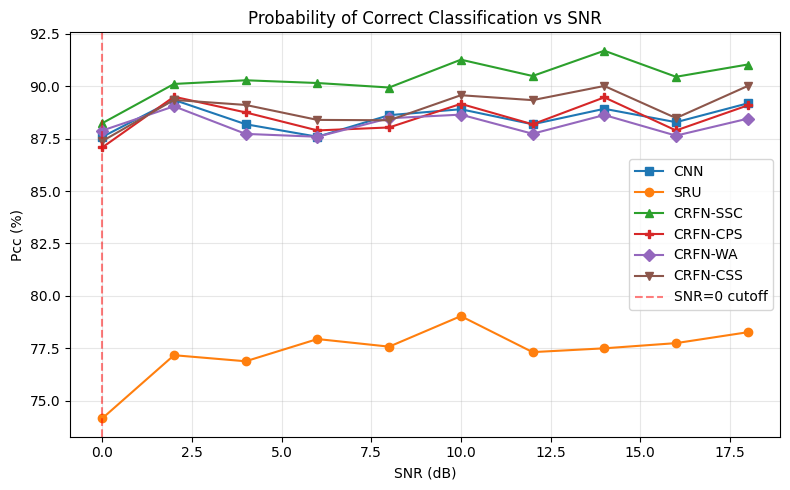


Average accuracy (SNR >= 0 dB, matching paper's Table 3):
  CNN         : 88.48%
  SRU         : 77.36%
  CRFN-SSC    : 90.36%
  CRFN-CPS    : 88.50%
  CRFN-WA     : 88.18%
  CRFN-CSS    : 89.00%

Average accuracy (ALL SNRs including noisy -20 to -2 dB):
  CNN         : 88.48%
  SRU         : 77.36%
  CRFN-SSC    : 90.36%
  CRFN-CPS    : 88.50%
  CRFN-WA     : 88.18%
  CRFN-CSS    : 89.00%


In [ ]:
#7
def wa_predict(X):
    return (trained['CNN'].predict(X, verbose=0) +
            trained['SRU'].predict(X, verbose=0)) / 2.0

def pcc_by_snr(model_or_fn, X, y_true, snr_arr):
    pcc = {}
    for snr in sorted(set(snr_arr)):
        mask = snr_arr == snr
        Xs, ys = X[mask], y_true[mask]
        if hasattr(model_or_fn, 'predict'):
            probs = model_or_fn.predict(Xs, verbose=0)
        else:
            probs = model_or_fn(Xs)
        pcc[snr] = (probs.argmax(1) == ys).mean() * 100
    return pcc

results = {}
for name in ['CNN','SRU','CRFN-SSC','CRFN-CPS','CRFN-CSS']:
    results[name] = pcc_by_snr(trained[name], X_test, y_test, snr_test)
results['CRFN-WA'] = pcc_by_snr(wa_predict, X_test, y_test, snr_test)

# Plot: all curve
snr_axis = sorted(set(snr_test))
plt.figure(figsize=(8, 5))
markers = {'CNN':'s','SRU':'o','CRFN-SSC':'^',
           'CRFN-CPS':'P','CRFN-WA':'D','CRFN-CSS':'v'}
for name in ['CNN','SRU','CRFN-SSC','CRFN-CPS','CRFN-WA','CRFN-CSS']:
    ys = [results[name][s] for s in snr_axis]
    plt.plot(snr_axis, ys, marker=markers[name], label=name)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='SNR=0 cutoff')
plt.xlabel('SNR (dB)'); plt.ylabel('Pcc (%)')
plt.title('Probability of Correct Classification vs SNR')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Average accuracy: SNR >= 0 only (matches paper's reporting range)
HIGH_SNRS = [s for s in snr_axis if s >= 0]

print("\nAverage accuracy (SNR >= 0 dB, matching paper's Table 3):")
for name in ['CNN','SRU','CRFN-SSC','CRFN-CPS','CRFN-WA','CRFN-CSS']:
    avg = np.mean([results[name][s] for s in HIGH_SNRS])
    print(f"  {name:12s}: {avg:.2f}%")

print("\nAverage accuracy (ALL SNRs including noisy -20 to -2 dB):")
for name in ['CNN','SRU','CRFN-SSC','CRFN-CPS','CRFN-WA','CRFN-CSS']:
    avg = np.mean(list(results[name].values()))
    print(f"  {name:12s}: {avg:.2f}%")

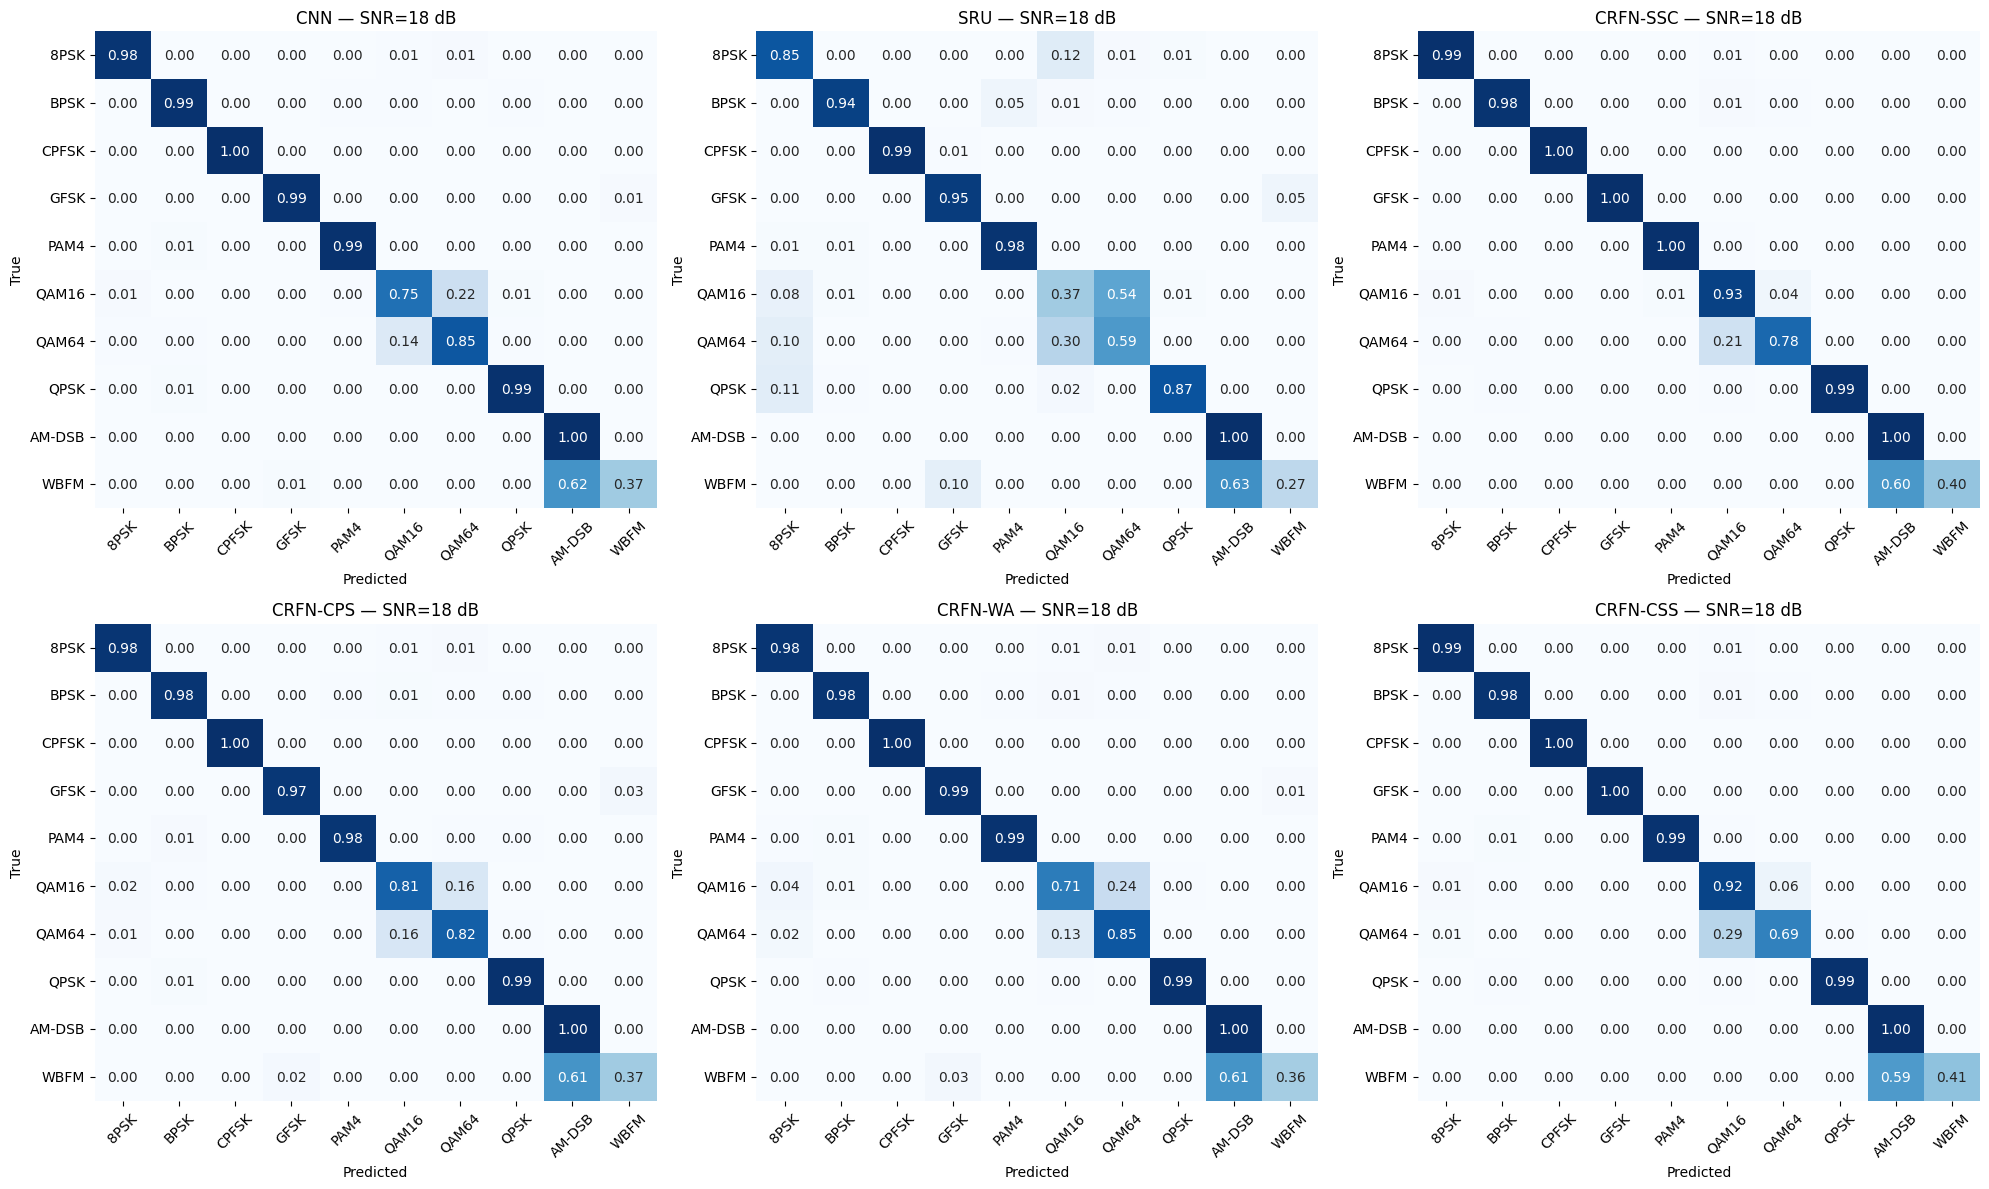

In [28]:
#8
# Use highest available SNR for clearest confusion matrices
top_snr = max(snr_test)
mask_top = snr_test == top_snr
X_top, y_top = X_test[mask_top], y_test[mask_top]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for ax, name in zip(axes.flat,
                    ['CNN','SRU','CRFN-SSC','CRFN-CPS','CRFN-WA','CRFN-CSS']):
    probs = wa_predict(X_top) if name == 'CRFN-WA' \
            else trained[name].predict(X_top, verbose=0)
    cm = confusion_matrix(y_top, probs.argmax(1),
                          labels=range(NUM_CLASSES), normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                vmin=0, vmax=1,
                xticklabels=classes, yticklabels=classes,
                ax=ax, cbar=False)
    ax.set_title(f'{name} — SNR={top_snr} dB')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()

--- MY IMPROVEMENTS ---


In [ ]:
#A

DRIVE_SAVE_PATH = '/content/drive/MyDrive/CSC330_Project/CNN_BiLSTM_Attention_v2.keras'

# Filter training data to SNR >= 0 only
# Low SNR samples (-20 to -2 dB) are pure noise and hurt accuracy
from sklearn.model_selection import train_test_split

good_mask = snrs >= 0
X_good    = X[good_mask]
y_good    = y[good_mask]
snrs_good = snrs[good_mask]

X_temp2, X_test2, y_temp2, y_test2, snrs_temp2, snr_test2 = train_test_split(
    X_good, y_good, snrs_good,
    test_size=0.2, random_state=SEED, stratify=y_good)

X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X_temp2, y_temp2,
    test_size=0.25, random_state=SEED, stratify=y_temp2)

y_train2_oh = tf.keras.utils.to_categorical(y_train2, NUM_CLASSES)
y_val2_oh   = tf.keras.utils.to_categorical(y_val2,   NUM_CLASSES)

print("Train:", X_train2.shape,
      "| Val:", X_val2.shape,
      "| Test:", X_test2.shape)
print("SNRs in training:", sorted(set(snrs_temp2)))

#  Residual Conv1D block 
def residual_conv_block(x, filters, kernel_size, p):
    shortcut = x
    x = layers.Conv1D(filters, kernel_size, padding='same',
                      activation='relu', name=f'{p}_c1')(x)
    x = layers.BatchNormalization(name=f'{p}_bn1')(x)
    x = layers.Dropout(0.3, name=f'{p}_d1')(x)
    x = layers.Conv1D(filters, kernel_size, padding='same',
                      activation='relu', name=f'{p}_c2')(x)
    x = layers.BatchNormalization(name=f'{p}_bn2')(x)
    # match dimensions for residual if needed
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same',
                                 name=f'{p}_proj')(shortcut)
    x = layers.Add(name=f'{p}_add')([x, shortcut])
    x = layers.Activation('relu', name=f'{p}_act')(x)
    return x

def build_cnn_bilstm_attention_v2():
    inp = Input(INPUT_SHAPE, name='cbla_in')

    # Stage 1: Residual Conv1D blocks
    x = layers.Conv1D(128, 7, padding='same', activation='relu',
                      name='cbla_stem')(inp)
    x = layers.BatchNormalization(name='cbla_stem_bn')(x)

    x = residual_conv_block(x, 128, 7, 'cbla_r1')
    x = residual_conv_block(x, 256, 5, 'cbla_r2')
    x = residual_conv_block(x, 256, 3, 'cbla_r3')

    # Stage 2: BiLSTM — no recurrent_dropout for cuDNN speed
    x = layers.Bidirectional(
            layers.LSTM(128, return_sequences=True, dropout=0.3),
            name='cbla_bilstm1')(x)
    x = layers.LayerNormalization(name='cbla_ln_lstm1')(x)

    x = layers.Bidirectional(
            layers.LSTM(64, return_sequences=True, dropout=0.3),
            name='cbla_bilstm2')(x)
    x = layers.LayerNormalization(name='cbla_ln_lstm2')(x)

    # Stage 3: Multi-head self-attention + residual
    attn = layers.MultiHeadAttention(
               num_heads=4, key_dim=32,
               name='cbla_mha')(x, x)
    attn = layers.Dropout(0.3, name='cbla_attn_drop')(attn)
    attn = layers.LayerNormalization(name='cbla_ln_attn')(attn + x)

    # Stage 4: Pool + classify
    x = layers.GlobalAveragePooling1D(name='cbla_gap')(attn)

    x = layers.Dense(256, activation='relu', name='cbla_fc1')(x)
    x = layers.BatchNormalization(name='cbla_fbn1')(x)
    x = layers.Dropout(0.4, name='cbla_fd1')(x)

    x = layers.Dense(128, activation='relu', name='cbla_fc2')(x)
    x = layers.BatchNormalization(name='cbla_fbn2')(x)
    x = layers.Dropout(0.4, name='cbla_fd2')(x)

    out = layers.Dense(NUM_CLASSES, activation='softmax', name='cbla_out')(x)

    return Model(inp, out, name='CNN_BiLSTM_Attention_v2')


if os.path.exists(DRIVE_SAVE_PATH):
    print("Found saved model in Drive, loading...")
    model_bilstm = tf.keras.models.load_model(DRIVE_SAVE_PATH)
    print("Model loaded successfully.")
else:
    print("Training from scratch...")
    model_bilstm = build_cnn_bilstm_attention_v2()
    print(f"Total params: {model_bilstm.count_params():,}")

    # Label smoothing helps generalization on RadioML
    model_bilstm.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy'])

    cbs = [
        EarlyStopping(monitor='val_accuracy', patience=15,
                      restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-7),
        tf.keras.callbacks.ModelCheckpoint(
            DRIVE_SAVE_PATH,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1)
    ]

    hist_bilstm = model_bilstm.fit(
        X_train2, y_train2_oh,
        validation_data=(X_val2, y_val2_oh),
        epochs=60, batch_size=128,
        callbacks=cbs, verbose=2)

    print(f"Saved to: {DRIVE_SAVE_PATH}")

Train: (60000, 128, 2) | Val: (20000, 128, 2) | Test: (20000, 128, 2)
SNRs in training: [np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(16), np.int64(18)]
Training from scratch...
Total params: 1,850,378
Epoch 1/60

Epoch 1: val_accuracy improved from None to 0.10010, saving model to /content/drive/MyDrive/CSC330_Project/CNN_BiLSTM_Attention_v2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CSC330_Project/CNN_BiLSTM_Attention_v2.keras
469/469 - 82s - 176ms/step - accuracy: 0.5785 - loss: 1.3815 - val_accuracy: 0.1001 - val_loss: 2.4337 - learning_rate: 0.0010
Epoch 2/60

Epoch 2: val_accuracy improved from 0.10010 to 0.76905, saving model to /content/drive/MyDrive/CSC330_Project/CNN_BiLSTM_Attention_v2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CSC330_Project/CNN_BiLSTM_Attention_v2.keras
469/469 - 64s - 136ms/step - accuracy: 0.7657 - loss: 0.9050 - val_accuracy: 0.7691 - val_los

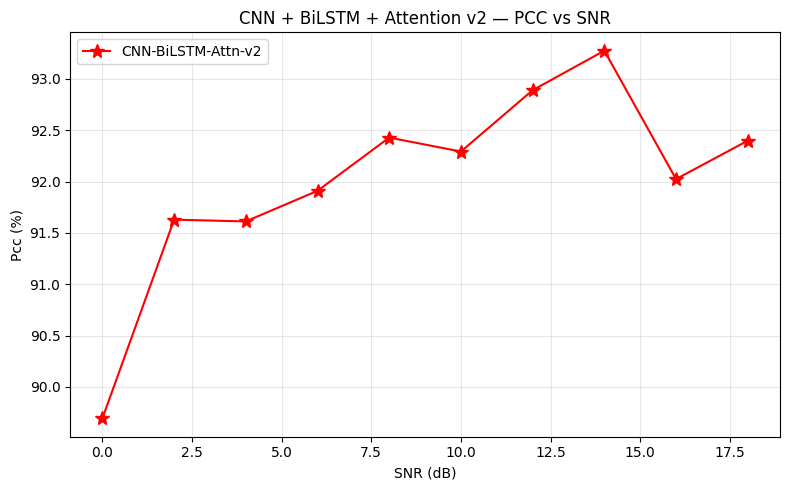

CNN-BiLSTM-Attn-v2 average accuracy (SNR >= 0): 92.01%

Per-SNR accuracy:
  SNR=  0dB: 89.69%
  SNR=  2dB: 91.63%
  SNR=  4dB: 91.61%
  SNR=  6dB: 91.91%
  SNR=  8dB: 92.43%
  SNR= 10dB: 92.29%
  SNR= 12dB: 92.89%
  SNR= 14dB: 93.27%
  SNR= 16dB: 92.02%
  SNR= 18dB: 92.40%


In [30]:
#B

def pcc_by_snr_single(model, X, y_true, snr_arr):
    pcc = {}
    for snr in sorted(set(snr_arr)):
        mask = snr_arr == snr
        probs = model.predict(X[mask], verbose=0)
        pcc[snr] = (probs.argmax(1) == y_true[mask]).mean() * 100
    return pcc

# Use the filtered test set
bilstm_results = pcc_by_snr_single(model_bilstm, X_test2, y_test2, snr_test2)

snr_axis = sorted(set(snr_test2))
plt.figure(figsize=(8, 5))
plt.plot(snr_axis, [bilstm_results[s] for s in snr_axis],
         marker='*', markersize=10, label='CNN-BiLSTM-Attn-v2', color='red')
plt.xlabel('SNR (dB)'); plt.ylabel('Pcc (%)')
plt.title('CNN + BiLSTM + Attention v2 — PCC vs SNR')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

HIGH_SNRS = [s for s in snr_axis if s >= 0]
avg_high = np.mean([bilstm_results[s] for s in HIGH_SNRS])
print(f"CNN-BiLSTM-Attn-v2 average accuracy (SNR >= 0): {avg_high:.2f}%")

# Per SNR breakdown
print("\nPer-SNR accuracy:")
for snr in snr_axis:
    print(f"  SNR={snr:3d}dB: {bilstm_results[snr]:.2f}%")

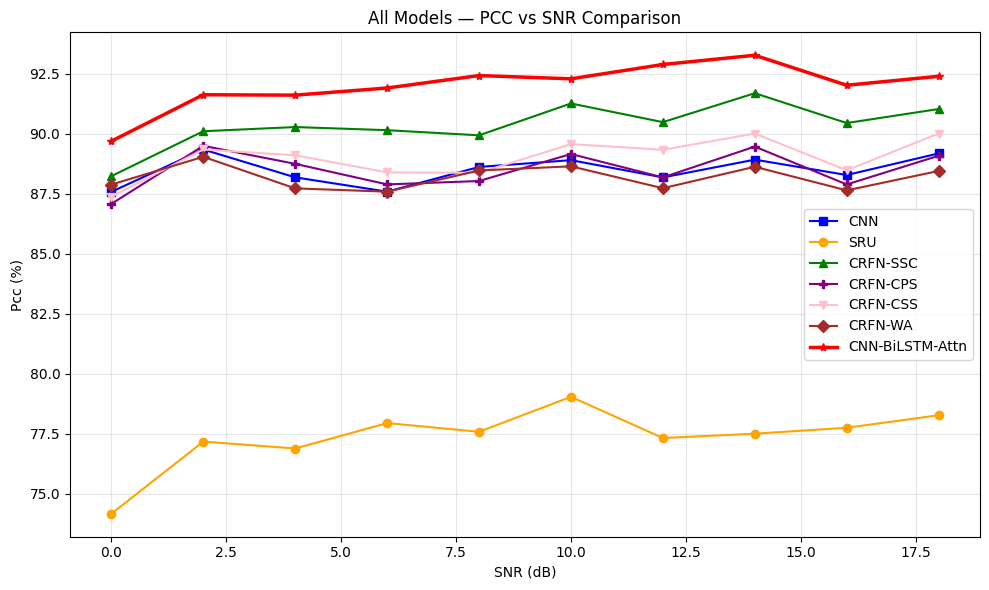


=== Final Accuracy Comparison (SNR >= 0 dB) ===
  CNN-BiLSTM-Attn       : 92.01%  ██████████████████████████████████████████████
  CRFN-SSC              : 90.36%  █████████████████████████████████████████████
  CRFN-CSS              : 89.00%  ████████████████████████████████████████████
  CRFN-CPS              : 88.50%  ████████████████████████████████████████████
  CNN                   : 88.48%  ████████████████████████████████████████████
  CRFN-WA               : 88.18%  ████████████████████████████████████████████
  SRU                   : 77.36%  ██████████████████████████████████████


In [31]:
#C

# Combine previous results with new model
all_results = {**results, 'CNN-BiLSTM-Attn': bilstm_results}

snr_axis = sorted(set(snr_test))
HIGH_SNRS = [s for s in snr_axis if s >= 0]

# Plot all models together
plt.figure(figsize=(10, 6))
markers = {'CNN':'s', 'SRU':'o', 'CRFN-SSC':'^', 'CRFN-CPS':'P',
           'CRFN-WA':'D', 'CRFN-CSS':'v', 'CNN-BiLSTM-Attn':'*'}
colors  = {'CNN':'blue', 'SRU':'orange', 'CRFN-SSC':'green',
           'CRFN-CPS':'purple', 'CRFN-WA':'brown',
           'CRFN-CSS':'pink', 'CNN-BiLSTM-Attn':'red'}

for name in all_results:
    ys = [all_results[name][s] for s in snr_axis]
    lw = 2.5 if name == 'CNN-BiLSTM-Attn' else 1.5
    plt.plot(snr_axis, ys, marker=markers[name],
             label=name, color=colors[name], linewidth=lw)

plt.xlabel('SNR (dB)'); plt.ylabel('Pcc (%)')
plt.title('All Models — PCC vs SNR Comparison')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Final comparison table
print("\n=== Final Accuracy Comparison (SNR >= 0 dB) ===")
rows = []
for name in all_results:
    avg = np.mean([all_results[name][s] for s in HIGH_SNRS])
    rows.append((name, avg))

rows.sort(key=lambda x: x[1], reverse=True)
for name, avg in rows:
    bar = '█' * int(avg / 2)
    print(f"  {name:22s}: {avg:5.2f}%  {bar}")

In [32]:
# C TENTATIVE snr_axis = sorted(set(snr_test2))
# HIGH_SNRS = [s for s in snr_axis if s >= 0]

# # Plot
# plt.figure(figsize=(8, 5))
# plt.plot(snr_axis, [bilstm_results[s] for s in snr_axis],
#          marker='*', markersize=10, label='CNN-BiLSTM-Attn', color='red')
# plt.xlabel('SNR (dB)'); plt.ylabel('Pcc (%)')
# plt.title('CNN + BiLSTM + Attention — PCC vs SNR')
# plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# # Accuracy table
# print("\n=== Final Accuracy Results ===")
# avg = np.mean([bilstm_results[s] for s in HIGH_SNRS])
# bar = '█' * int(avg / 2)
# print(f"  {'CNN-BiLSTM-Attn':22s}: {avg:5.2f}%  {bar}")

# print("\nPer-SNR breakdown:")
# for snr in snr_axis:
#     print(f"  SNR={snr:3d}dB: {bilstm_results[snr]:.2f}%")